In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
#read cleaned data
df = pd.read_csv('../data/netflix_cleaned.csv')
#check data
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              235 non-null    object 
 1   rating             235 non-null    object 
 2   ratinglevel        235 non-null    object 
 3   ratingdescription  235 non-null    int64  
 4   release_year       235 non-null    int64  
 5   user_rating_score  235 non-null    float64
 6   user_rating_size   235 non-null    int64  
 7   show_id            235 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 14.8+ KB


,ratingdescription,release_year,user_rating_score,user_rating_size,show_id
count,235.000000,235.000000,235.000000,235.0,235.000000
mean,74.697872,2011.506383,81.727660,80.0,118.000000
std,26.566120,6.198546,12.635686,0.0,67.982841
min,10.000000,1994.000000,55.000000,80.0,1.000000
25%,60.000000,2008.000000,72.000000,80.0,59.500000
50%,90.000000,2015.000000,84.000000,80.0,118.000000
75%,90.000000,2016.000000,93.000000,80.0,176.500000
max,124.000000,2017.000000,99.000000,80.0,235.000000


In [6]:
#Content Distribution
#How many titles are in the dataset?
df["show_id"].nunique()

235

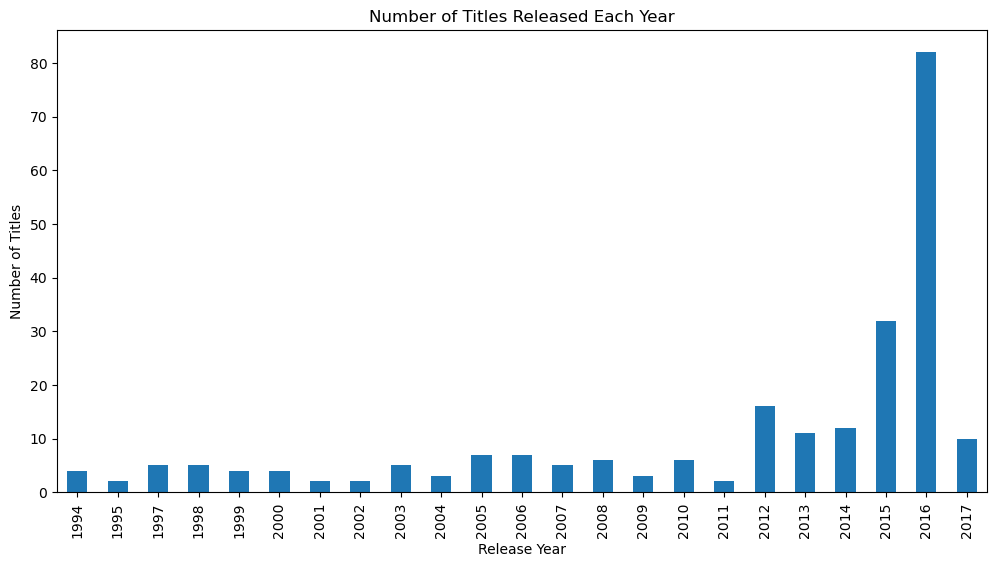

In [7]:
#How many titles were released each year?
df["release_year"].value_counts().sort_index().plot(kind="bar", figsize=(12, 6))
plt.title("Number of Titles Released Each Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()


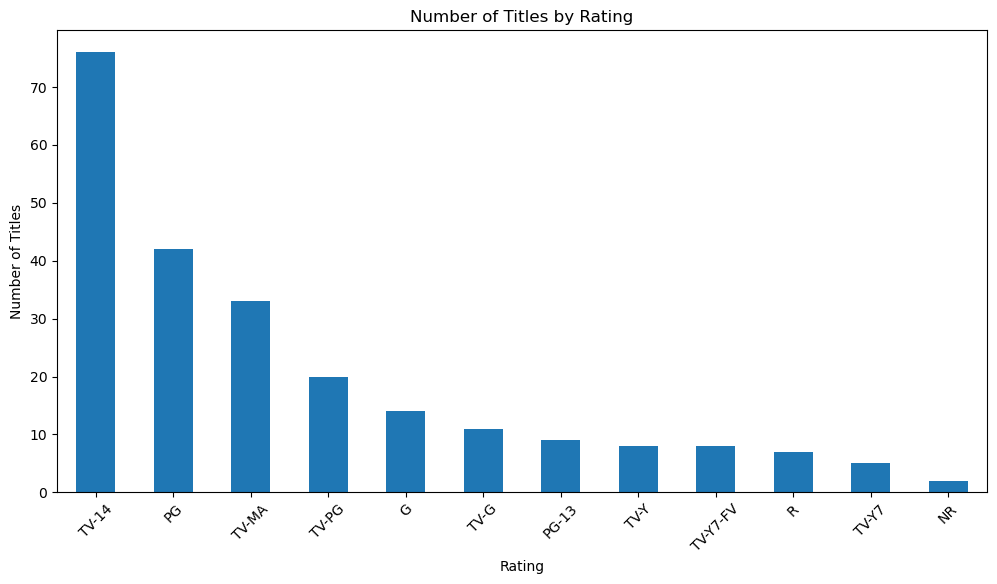

Percentage of family-friendly content: 18.72%


In [9]:
#Rating based Questions
#What are the different ratings available in the dataset?
df["rating"].value_counts()
#Which rating category has the most titles?
df["rating"].value_counts().plot(kind="bar", figsize=(12, 6))
plt.title("Number of Titles by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()
#What percentage of content is family-friendly?
family_friendly = df[df["rating"].isin(["TV-Y", "TV-Y7", "TV-G", "TV-PG"])]
family_friendly_percentage = (len(family_friendly) / len(df)) * 100
print(f"Percentage of family-friendly content: {family_friendly_percentage:.2f}%")




Average user rating: 81.73
Top 10 highest-rated titles:
                       title  user_rating_score
25            13 Reasons Why               99.0
47              Finding Dory               98.0
9           Once Upon a Time               98.0
119                     Lost               98.0
39   Orange Is the New Black               98.0
33                   Friends               98.0
32            Criminal Minds               98.0
31                Family Guy               98.0
21                 The Flash               98.0
1             Grey's Anatomy               98.0
Correlation between user ratings and release year: 0.15


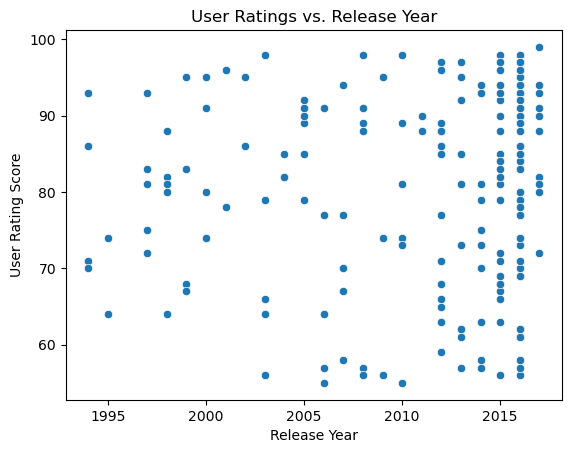

Top 10 lowest-rated titles:
                                title  user_rating_score
78                    Life Unexpected               55.0
215                    Curious George               55.0
178                      PokÃ©mon: XY               56.0
128                            Bitten               56.0
206  DreamWorks Shrek's Swamp Stories               56.0
88       How to Lose a Guy in 10 Days               56.0
94          Hannah Montana: The Movie               56.0
159         Star Wars: The Clone Wars               57.0
18             Hunter X Hunter (2011)               57.0
151        The Doctor Blake Mysteries               57.0


In [11]:
#User Rating Analysis
#What is the average user rating for movies and TV shows?
average_rating = df["user_rating_score"].mean()
print(f"Average user rating: {average_rating:.2f}")
#Which titles have the highest user ratings?
top_rated = df.sort_values(by="user_rating_score", ascending=False).head(10)
print("Top 10 highest-rated titles:")
print(top_rated[["title", "user_rating_score"]])
#Is there a correlation between user ratings and release year?
correlation = df["user_rating_score"].corr(df["release_year"])
print(f"Correlation between user ratings and release year: {correlation:.2f}")
sns.scatterplot(x="release_year", y="user_rating_score", data=df)
plt.title("User Ratings vs. Release Year")
plt.xlabel("Release Year")
plt.ylabel("User Rating Score")
plt.show()
#Which titles have the lowest user ratings?
lowest_rated = df.sort_values(by="user_rating_score").head(10)
print("Top 10 lowest-rated titles:")
print(lowest_rated[["title", "user_rating_score"]])
    



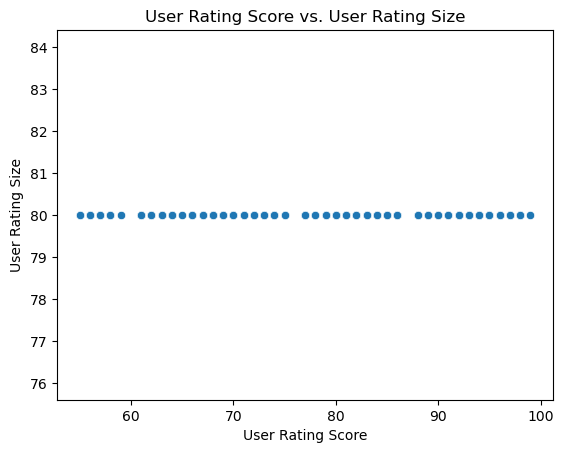

Correlation between user ratings and user rating size: nan


c:\Users\Jiya Yadav\anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Jiya Yadav\anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [14]:
#Rating vs. popularity
#Do higher-rated titles receive larger rating sizes?
sns.scatterplot(x="user_rating_score", y="user_rating_size", data=df)
plt.title("User Rating Score vs. User Rating Size")
plt.xlabel("User Rating Score")
plt.ylabel("User Rating Size")
plt.show()

#Is there a correlation between user ratings and user rating size?
correlation_rating_size = df["user_rating_score"].corr(df["user_rating_size"])
print(f"Correlation between user ratings and user rating size: {correlation_rating_size:.2f}")


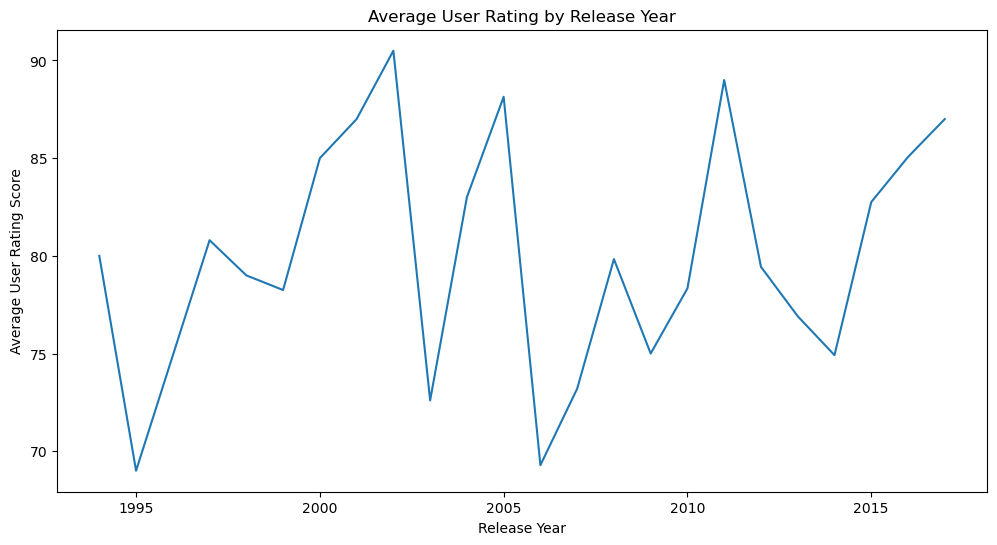

Release year with the highest average user rating: 2002
Release year with the lowest average user rating: 1995


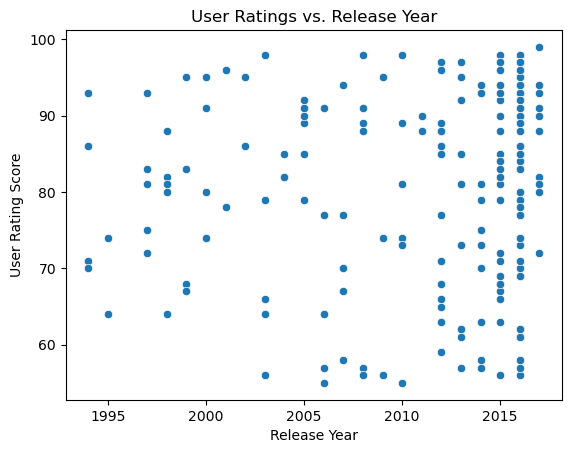

In [15]:
#RELEASE YEAR ANALYSIS      
#What is the average user rating by release year?
average_rating_by_year = df.groupby("release_year")["user_rating_score"].mean()
plt.figure(figsize=(12, 6))
average_rating_by_year.plot(kind="line")
plt.title("Average User Rating by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average User Rating Score")
plt.show()
#Which release year has the highest average user rating?
highest_avg_rating_year = average_rating_by_year.idxmax()
print(f"Release year with the highest average user rating: {highest_avg_rating_year}")
#Which release year has the lowest average user rating?
lowest_avg_rating_year = average_rating_by_year.idxmin()
print(f"Release year with the lowest average user rating: {lowest_avg_rating_year}")
#Are newer titles rated better than older ones? 
sns.scatterplot(x="release_year", y="user_rating_score", data=df)
plt.title("User Ratings vs. Release Year")
plt.xlabel("Release Year")
plt.ylabel("User Rating Score")
plt.show()


In [16]:
#Audience Preference
#Which rating category gets the highest average user score?
average_rating_by_category = df.groupby("rating")["user_rating_score"].mean().sort_values(ascending=False)
print("Average user rating by rating category:")
print(average_rating_by_category)
#Which rating category gets the lowest average user score?
average_rating_by_category = df.groupby("rating")["user_rating_score"].mean().sort_values()
print("Average user rating by rating category:")
print(average_rating_by_category)
#Which rating category has the largest audience size?
average_rating_size_by_category = df.groupby("rating")["user_rating_size"].mean().sort_values(ascending=False)
print("Average user rating size by rating category:")
print(average_rating_size_by_category)
#Which rating category has the smallest audience size?
average_rating_size_by_category = df.groupby("rating")["user_rating_size"].mean().sort_values()
print("Average user rating size by rating category:")
print(average_rating_size_by_category)
#Is there a correlation between rating category and user rating score?
correlation_category_rating = df["rating"].astype('category').cat.codes.corr(df["user_rating_score"])
print(f"Correlation between rating category and user rating score: {correlation_category_rating:.2f}")



Average user rating by rating category:
rating
R           85.285714
PG          85.238095
TV-MA       85.151515
TV-PG       84.950000
TV-14       82.750000
TV-Y7       78.800000
NR          77.000000
TV-Y        75.000000
TV-G        74.363636
G           74.285714
TV-Y7-FV    72.750000
PG-13       71.444444
Name: user_rating_score, dtype: float64
Average user rating by rating category:
rating
PG-13       71.444444
TV-Y7-FV    72.750000
G           74.285714
TV-G        74.363636
TV-Y        75.000000
NR          77.000000
TV-Y7       78.800000
TV-14       82.750000
TV-PG       84.950000
TV-MA       85.151515
PG          85.238095
R           85.285714
Name: user_rating_score, dtype: float64
Average user rating size by rating category:
rating
G           80.0
NR          80.0
PG          80.0
PG-13       80.0
R           80.0
TV-14       80.0
TV-G        80.0
TV-MA       80.0
TV-PG       80.0
TV-Y        80.0
TV-Y7       80.0
TV-Y7-FV    80.0
Name: user_rating_size, dtype: float64
Ave

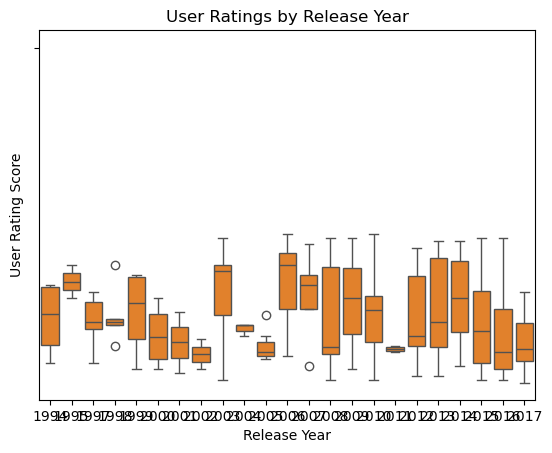

In [17]:
#Outlier Analysis
#Are there any outliers in user ratings?
sns.boxplot(x=df["user_rating_score"])
#Are there release years with unusually high ratings?
sns.boxplot(x=df["release_year"], y=df["user_rating_score"])
plt.title("User Ratings by Release Year")
plt.xlabel("Release Year")
plt.ylabel("User Rating Score")
plt.show()


<Axes: >

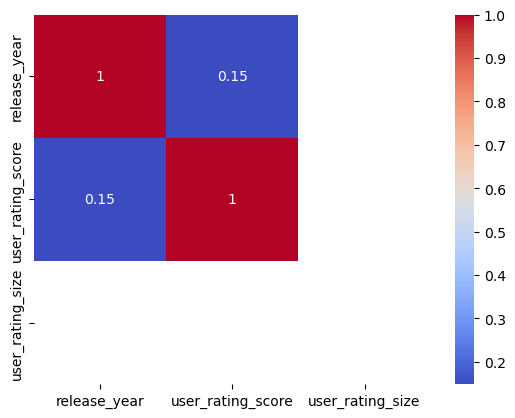

In [18]:
#Correlation Analysis
#Is there a relationship between:Release Year, User Rating Score and User Rating Size?
correlation_matrix = df[["release_year", "user_rating_score", "user_rating_size"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")    
